Alberto Morillas has 499 perfumes.


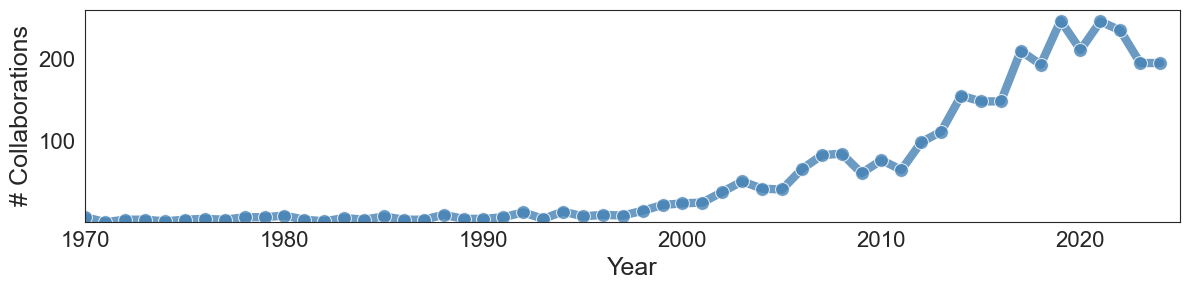

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import ast
import numpy as np
import math
from itertools import combinations
import graph_tool.all as gt
import seaborn as sns

def parse_perfumers(perfumer_str):
    """
    Parse the 'perfumer' column to extract individual perfumers.
    If the cell is a string representation of a list, use ast.literal_eval.
    """
    try:
        if pd.isna(perfumer_str):
            return []
        s = perfumer_str.strip()
        # If it looks like a list, parse it
        if s.startswith('[') and s.endswith(']'):
            parsed = ast.literal_eval(s)
            if isinstance(parsed, list):
                return [str(name).strip() for name in parsed if str(name).strip() != ""]
            else:
                cleaned = str(parsed).strip()
                return [cleaned] if cleaned != "" else []
        else:
            return [p.strip() for p in s.split(",") if p.strip() != ""]
    except Exception:
        return []

def parse_accords(accords_str):
    """
    Parse the 'accords' column to extract accord frequencies.
    """
    try:
        return ast.literal_eval(accords_str)
    except (ValueError, SyntaxError):
        return {}

def calculate_dominant_accord(perfumer_accords):
    """
    Calculate the dominant accord for each perfumer based on accord frequencies,
    considering all accords present.
    
    For each perfumer, this function aggregates the frequencies of each accord 
    (by summing them) and then returns the accord with the highest total frequency.
    """
    aggregated = perfumer_accords.groupby(['perfumer', 'accord'])['frequency'].sum().reset_index()
    # For each perfumer, select the row with the maximum frequency
    idx = aggregated.groupby('perfumer')['frequency'].idxmax()
    dominant = aggregated.loc[idx].reset_index(drop=True)
    dominant = dominant.rename(columns={'accord': 'dominant_accord'})
    return dominant

def main():
    # Load the dataset
    csv_file = "../dataset/perfume_dataset.csv"  # Update this path as needed
    try:
        df = pd.read_csv(csv_file)
    except FileNotFoundError:
        print(f"File {csv_file} not found!")
        return

    # ------------------------------------------------------
    # Ensure 'year' is treated as an integer, if your data has that column
    # If your dataset calls this something else (e.g. 'release_year'), adjust accordingly.
    # Remove or modify this if your dataset lacks a year column.
    if 'year' in df.columns:
        df = df.dropna(subset=['year'])          # drop rows with no year
        df['year'] = df['year'].astype(int)      # convert to integer
    # ------------------------------------------------------

    # Parse the 'perfumer' and 'accords' columns
    df['parsed_perfumers'] = df['perfumer'].apply(parse_perfumers)
    df['parsed_accords']   = df['accords'].apply(parse_accords)

    # Flatten the accords and associate them with perfumers
    accord_data = []
    for _, row in df.iterrows():
        perfumers = row['parsed_perfumers']
        accords = row['parsed_accords']
        for perfumer in perfumers:
            for accord, frequency in accords.items():
                accord_data.append({'perfumer': perfumer, 'accord': accord, 'frequency': frequency})
    perfumer_accords = pd.DataFrame(accord_data)

    # Identify the top 15 most frequent accords
    top_accords = (
        perfumer_accords.groupby('accord')['frequency']
        .sum()
        .sort_values(ascending=False)
        .head(15)
        .index.tolist()
    )

    # Calculate the dominant accord for each perfumer
    dominant_accords = calculate_dominant_accord(perfumer_accords)
    perfumer_accord_map = dominant_accords.set_index('perfumer')['dominant_accord'].to_dict()

    # Count perfumes for each perfumer
    perfumer_counts = (
        df.explode('parsed_perfumers')
        .dropna(subset=['parsed_perfumers'])
        .groupby('parsed_perfumers')['id']
        .count()
        .reset_index()
        .rename(columns={'parsed_perfumers': 'perfumer', 'id': 'perfume_count'})
    )
    # Example check for Alberto Morillas
    alberto = perfumer_counts[perfumer_counts['perfumer'].str.lower() == 'alberto morillas']
    if not alberto.empty:
        print("Alberto Morillas has", alberto['perfume_count'].values[0], "perfumes.")
    else:
        print("No data for Alberto Morillas.")

    perfumer_size_map = perfumer_counts.set_index('perfumer')['perfume_count'].to_dict()

    # Filter to keep perfumers with more than 1 perfume
    top_perfumers = perfumer_counts[perfumer_counts['perfume_count'] > 1]['perfumer'].tolist()
    df['filtered_perfumers'] = df['parsed_perfumers'].apply(lambda x: [p for p in x if p in top_perfumers])
    df = df[df['filtered_perfumers'].apply(len) > 1]




    # ------------------------------------------------------
    # ADDITION: Calculate & plot the number of collaborations each year (1900–2024)
    # ------------------------------------------------------

    # 1) We assume 'year' is in df. Filter to collaborative perfumes only:
    # (We've already done that in df, so "df" at this point has only top-perfumers 
    #  with multiple perfumers. If you prefer the entire set, use a separate variable.)
    if 'year' in df.columns:
        # 2) Filter to the desired year range
        collab_df = df[(df['year'] >= 1900) & (df['year'] <= 2024)]

        # 3) Count how many collaborations for each year
        #    Each row in df is one perfume. Because we already have 
        #    'filtered_perfumers' length > 1, each row is a collaboration perfume.
        #    So we just need to count them by year.
        collab_year_counts = collab_df.groupby('year').size().sort_index()

        # 4) Make a list/array of years from 1900 to 2024, filling missing years with 0
        years = range(1970, 2025)
        year_counts = [collab_year_counts.get(y, 0) for y in years]

        # 5) Plot
        # Optional: set a style, e.g. "whitegrid"
        sns.set_style("white")

        plt.figure(figsize=(12, 3))
        ax = sns.lineplot(x=years, y=year_counts, color='steelblue',alpha=0.8,linewidth=6, marker='o',markersize=10)
        # Remove top and right spines
        # ax.spines["top"].set_visible(False)
        # ax.spines["right"].set_visible(False)
        # plt.yscale('symlog', linthresh=0.0001)  # or just plt.yscale('log') if you prefer

        plt.xlabel("Year", fontsize=18)
        plt.ylabel("# Collaborations", fontsize=18)
        plt.tick_params(axis='both', which='major', labelsize=16)
        plt.xlim(1970, 2025)
        plt.ylim(0.5, 260)

        plt.tight_layout()
        plt.savefig("../output/Figure_4a.svg", format="svg", dpi=300, bbox_inches="tight")

        plt.show()
    else:
        print("No 'year' column found in DataFrame—cannot plot collaborations over time.")

if __name__ == "__main__":
    main()


                   perfumer        accord   frequency
11570  Christophe Laudamiel         nutty  100.000000
11553  Christophe Laudamiel     chocolate   96.038614
11566  Christophe Laudamiel       leather   84.725624
11575  Christophe Laudamiel          rose   80.618487
11554  Christophe Laudamiel        citrus   75.982638
11545  Christophe Laudamiel         amber   75.656794
11556  Christophe Laudamiel        floral   74.459399
11547  Christophe Laudamiel       aquatic   73.202240
11560  Christophe Laudamiel         green   72.616701
11571  Christophe Laudamiel           oud   72.464027
11572  Christophe Laudamiel        ozonic   72.453190
11548  Christophe Laudamiel      aromatic   68.382273
11587  Christophe Laudamiel         woody   67.147718
11585  Christophe Laudamiel  white floral   66.576300
11559  Christophe Laudamiel        fruity   65.070277
11563  Christophe Laudamiel          iris   64.876538
11574  Christophe Laudamiel       powdery   64.649908
11576  Christophe Laudamiel 

/var/folders/ts/n9fbfxkj091_fpcsbsgj4zcxb6n5sd/T/ipykernel_47711/824054433.py:210: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(accords))


Nodes in largest component: 501


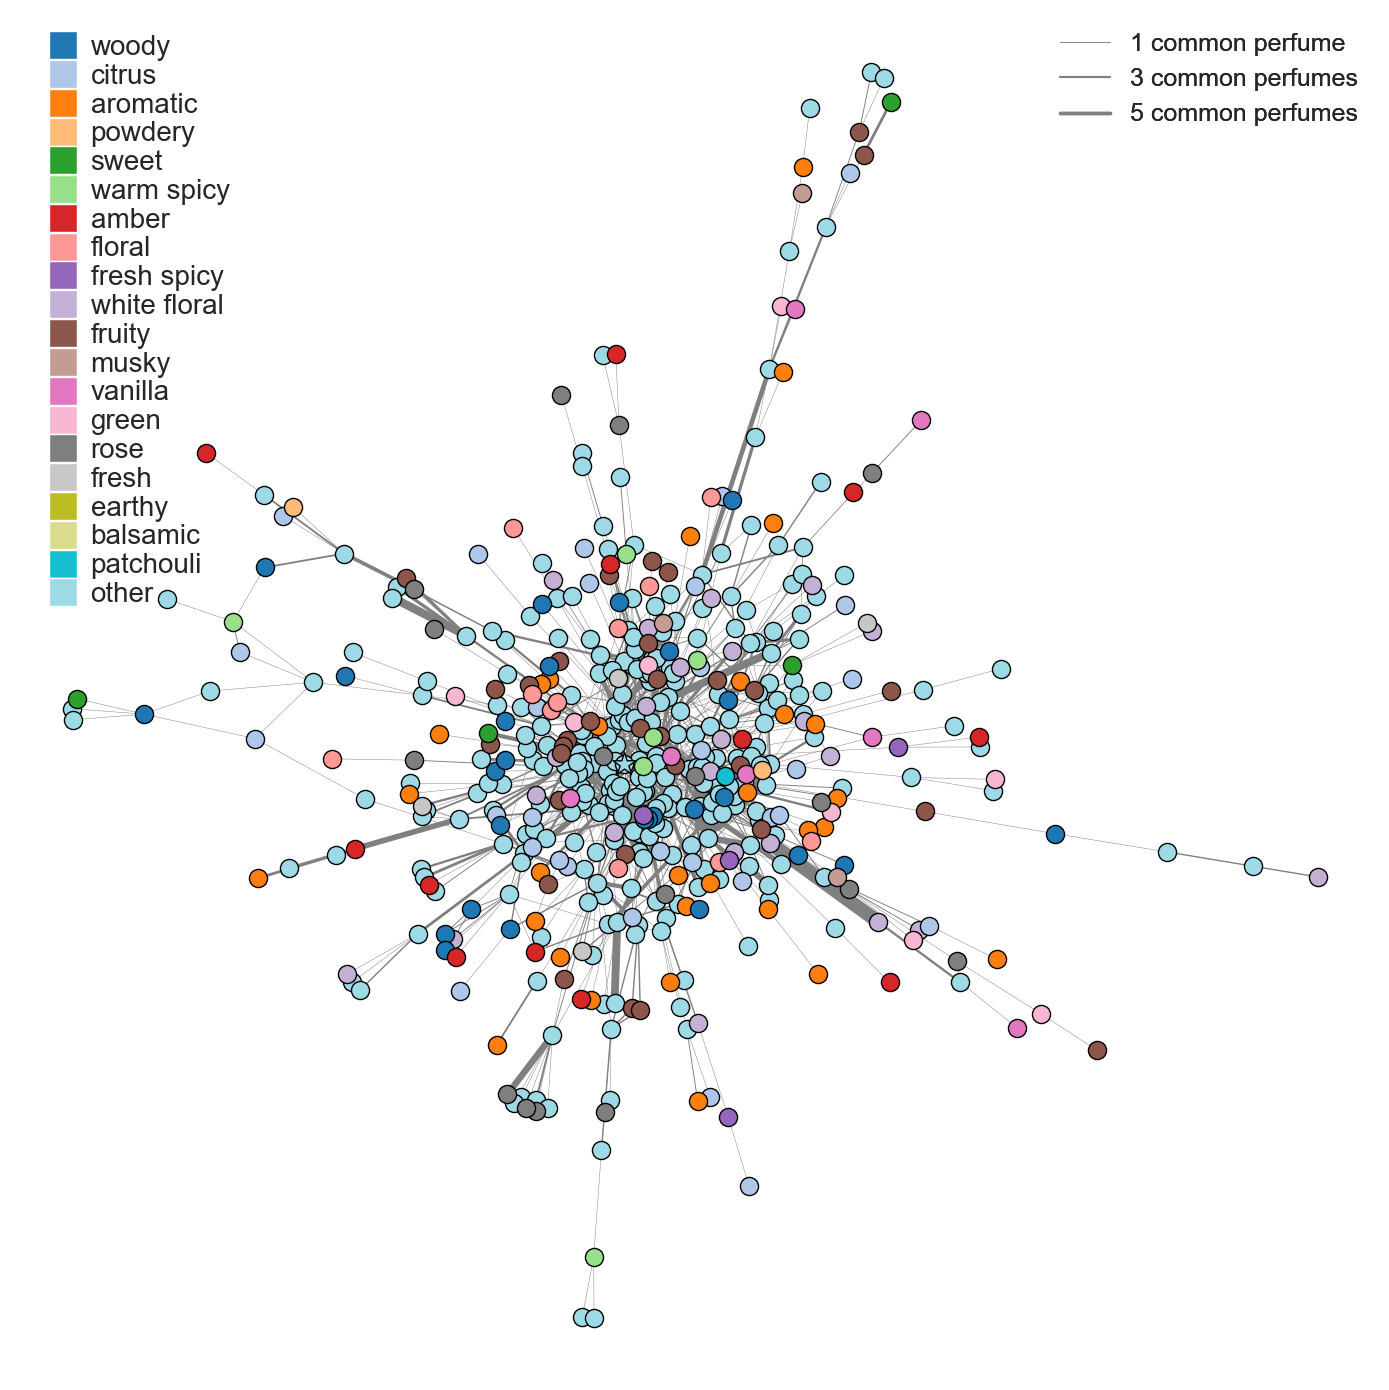

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import ast
import numpy as np
import math
from itertools import combinations
import graph_tool.all as gt

def parse_perfumers(perfumer_str):
    """
    Parse the 'perfumer' column to extract individual perfumers.
    If the cell is a string representation of a list, use ast.literal_eval.
    """
    try:
        if pd.isna(perfumer_str):
            return []
        s = perfumer_str.strip()
        # If it looks like a list, parse it
        if s.startswith('[') and s.endswith(']'):
            parsed = ast.literal_eval(s)
            if isinstance(parsed, list):
                return [str(name).strip() for name in parsed if str(name).strip() != ""]
            else:
                cleaned = str(parsed).strip()
                return [cleaned] if cleaned != "" else []
        else:
            return [p.strip() for p in s.split(",") if p.strip() != ""]
    except Exception:
        return []

def parse_accords(accords_str):
    """
    Parse the 'accords' column to extract accord frequencies.
    """
    try:
        return ast.literal_eval(accords_str)
    except (ValueError, SyntaxError):
        return {}

# def calculate_dominant_accord(perfumer_accords, top_accords):
#     """
#     Calculate the dominant accord for each perfumer based on accord frequencies,
#     considering only the top accords.
#     """
#     aggregated_accords = (
#         perfumer_accords.groupby(['perfumer', 'accord'])
#         .sum('frequency')
#         .reset_index()
#         .sort_values(['perfumer', 'frequency'], ascending=[True, False])
#     )
#     dominant_accords = (
#         aggregated_accords.groupby('perfumer')
#         .first()
#         .reset_index()
#         .rename(columns={'accord': 'dominant_accord'})
#     )
#     dominant_accords['dominant_accord'] = dominant_accords['dominant_accord'].apply(
#         lambda x: x if x in top_accords else 'other'
#     )
#     return dominant_accords
# def calculate_dominant_accord(perfumer_accords, top_accords):
#     aggregated_accords = (
#         perfumer_accords.groupby(['perfumer', 'accord'])
#         .sum('frequency')
#         .reset_index()
#         .sort_values(['perfumer', 'frequency'], ascending=[True, False])
#     )
#     # Let's see what we have for Christophe Laudamiel
#     chris_rows = aggregated_accords[aggregated_accords['perfumer'] == 'Christophe Laudamiel']
#     print(chris_rows.sort_values(by='frequency', ascending=False).head(20))
#     dominant_accords = (
#         aggregated_accords.groupby('perfumer')
#         .first()      # <-- picks the single largest SUM for each perfumer
#         .reset_index()
#         .rename(columns={'accord': 'dominant_accord'})
#     )
#     dominant_accords['dominant_accord'] = dominant_accords['dominant_accord'].apply(
#         lambda x: x if x in top_accords else 'other'
#     )
#     return dominant_accords

def calculate_dominant_accord(perfumer_accords, top_accords):
    aggregated_accords = (
        perfumer_accords.groupby(['perfumer', 'accord'])['frequency']  # Select 'frequency' column
        .mean()
        .reset_index()
        .sort_values(['perfumer', 'frequency'], ascending=[True, False])
    )
    # Let's see what we have for Christophe Laudamiel
    chris_rows = aggregated_accords[aggregated_accords['perfumer'] == 'Christophe Laudamiel']
    print(chris_rows.sort_values(by='frequency', ascending=False).head(20))
    dominant_accords = (
        aggregated_accords.groupby('perfumer')
        .first()
        .reset_index()
        .rename(columns={'accord': 'dominant_accord'})
    )
    dominant_accords['dominant_accord'] = dominant_accords['dominant_accord'].apply(
        lambda x: x if x in top_accords else 'other'
    )
    return dominant_accords



# def calculate_dominant_accord(perfumer_accords):
#     """
#     Calculate the dominant accord for each perfumer based on accord frequencies,
#     considering all accords present.
    
#     For each perfumer, this function aggregates the frequencies of each accord 
#     (by summing them) and then returns the accord with the highest total frequency.
#     """
#     aggregated = perfumer_accords.groupby(['perfumer', 'accord'])['frequency'].sum().reset_index()
#     # For each perfumer, select the row with the maximum frequency
#     idx = aggregated.groupby('perfumer')['frequency'].idxmax()
#     dominant = aggregated.loc[idx].reset_index(drop=True)
#     dominant = dominant.rename(columns={'accord': 'dominant_accord'})
#     return dominant

def main():
    # Load the dataset
    csv_file = "../dataset/perfume_dataset.csv"  # Update this path as needed
    try:
        df = pd.read_csv(csv_file)
        df = df[(df['year'] >= 1900)]
    except FileNotFoundError:
        print(f"File {csv_file} not found!")
        return

    # Parse the 'perfumer' and 'accords' columns
    df['parsed_perfumers'] = df['perfumer'].apply(parse_perfumers)
    df['parsed_accords'] = df['accords'].apply(parse_accords)

    # Flatten the accords and associate them with perfumers
    accord_data = []
    for _, row in df.iterrows():
        perfumers = row['parsed_perfumers']
        accords = row['parsed_accords']
        for perfumer in perfumers:
            for accord, frequency in accords.items():
                accord_data.append({'perfumer': perfumer, 'accord': accord, 'frequency': frequency})
    perfumer_accords = pd.DataFrame(accord_data)

    # Identify the top 15 most frequent accords
    top_accords = (
        perfumer_accords.groupby('accord')['frequency']
        .sum()
        .sort_values(ascending=False)
        .head(19)
        .index.tolist()
    )

    # Calculate the dominant accord for each perfumer
    dominant_accords = calculate_dominant_accord(perfumer_accords, top_accords)
    perfumer_accord_map = dominant_accords.set_index('perfumer')['dominant_accord'].to_dict()

    # Count perfumes for each perfumer
    perfumer_counts = (
        df.explode('parsed_perfumers')
        .dropna(subset=['parsed_perfumers'])
        .groupby('parsed_perfumers')['id']
        .count()
        .reset_index()
        .rename(columns={'parsed_perfumers': 'perfumer', 'id': 'perfume_count'})
    )
    alberto = perfumer_counts[perfumer_counts['perfumer'].str.lower() == 'alberto morillas']
    if not alberto.empty:
        print("Alberto Morillas has", alberto['perfume_count'].values[0], "perfumes.")
    else:
        print("No data for Alberto Morillas.")

    perfumer_size_map = perfumer_counts.set_index('perfumer')['perfume_count'].to_dict()

    # Filter to keep perfumers with more than 1 perfume
    top_perfumers = perfumer_counts[perfumer_counts['perfume_count'] > 0]['perfumer'].tolist()
    df['filtered_perfumers'] = df['parsed_perfumers'].apply(lambda x: [p for p in x if p in top_perfumers])
    df = df[df['filtered_perfumers'].apply(len) > 0]

    # Create edges with weights (number of common perfumes)
    edge_weights = {}
    for perfumers in df['filtered_perfumers']:
        for pair in combinations(perfumers, 2):
            if pair in edge_weights:
                edge_weights[pair] += 1
            else:
                edge_weights[pair] = 1

    # Build the graph using graph-tool
    g = gt.Graph(directed=False)
    v_label = g.new_vertex_property("string")      # Vertex label property (perfumer name)
    v_color = g.new_vertex_property("vector<double>")  # Vertex color (RGBA as list of 4 floats)
    v_size = g.new_vertex_property("double")         # Vertex size property
    e_weight = g.new_edge_property("int")            # Edge weight property
    e_width = g.new_edge_property("double")          # Edge line width property

    # Get the unique set of perfumers (nodes) from the edges
    nodes = set()
    for pair in edge_weights:
        nodes.update(pair)
    nodes = list(nodes)
    perfumer_to_vertex = {}
    for perfumer in nodes:
        v = g.add_vertex()
        perfumer_to_vertex[perfumer] = v
        v_label[v] = perfumer
        # Use a constant size (or adjust using perfumer_size_map if desired)
        v_size[v] = 170  
    # Prepare a color mapping based on dominant accords
    accords = top_accords + ['other']
    cmap = plt.cm.get_cmap('tab20', len(accords))
    accord_color_map = {accord: list(cmap(i)) for i, accord in enumerate(accords)}
    for perfumer, v in perfumer_to_vertex.items():
        dominant = perfumer_accord_map.get(perfumer, 'other')
        color = accord_color_map.get(dominant, [0.5, 0.5, 0.5, 1.0])
        v_color[v] = color

    # Add edges with weight and corresponding line width (weight/3)
    for (p1, p2), weight in edge_weights.items():
        v1 = perfumer_to_vertex[p1]
        v2 = perfumer_to_vertex[p2]
        e = g.add_edge(v1, v2)
        e_weight[e] = weight
        e_width[e] = weight / 3.0

    # Extract the largest connected component
    g_largest = gt.extract_largest_component(g)
    print(f"Nodes in largest component: {g_largest.num_vertices()}")

    # Compute layout using graph-tool's spring layout (sfdp_layout)
    # pos = gt.arf_layout(g_largest)
    # pos=gt.arf_layout(g_largest, weight=None, d=0.5, a=10, dt=0.001, epsilon=1e-06, max_iter=1, pos=None, dim=2)
    pos=gt.fruchterman_reingold_layout(g_largest, weight=None, a=None, r=11.0, scale=None, circular=False, grid=False, t_range=None, n_iter=1000, pos=None)

    # --- Now use matplotlib to manually draw the network ---
    plt.figure(figsize=(14, 14))

    # Draw edges manually
    for e in g_largest.edges():
        source = e.source()
        target = e.target()
        x_coords = [pos[source][0], pos[target][0]]
        y_coords = [pos[source][1], pos[target][1]]
        plt.plot(x_coords, y_coords, color="gray", linewidth=e_width[e])

    # Group vertices by their color (accord) for legend purposes
    color_groups = {}
    for v in g_largest.vertices():
        x, y = pos[v]
        col = tuple(v_color[v])
        if col not in color_groups:
            color_groups[col] = {'x': [], 'y': []}
        color_groups[col]['x'].append(x)
        color_groups[col]['y'].append(y)

    # Plot the vertices
    for col_key, data in color_groups.items():
        plt.scatter(data['x'], data['y'], s=170, color=[col_key], zorder=3, edgecolors='black')
    target_perfumer = "Alberto Morillas"
    if target_perfumer in perfumer_to_vertex:
        v = perfumer_to_vertex[target_perfumer]
        x, y = pos[v]
        c = tuple(v_color[v])
        # Re-plot this single node as a star marker:
        plt.scatter(
            x, 
            y, 
            s=300, 
            color=[c], 
            zorder=4, 
            edgecolors='black', 
            marker='*'   # <-- star marker
        )
    # Create a legend for accords using the color mapping
    legend_elements = [
        plt.Line2D([0], [0], marker='s', color='w', label=accord,
                   markerfacecolor=accord_color_map[accord], markersize=20)
        for accord in accord_color_map
    ]
    legend_accord = plt.legend(handles=legend_elements, title="", loc='upper left',
                               fontsize=20, frameon=False, labelspacing=0.1, handletextpad=0.0)
    plt.gca().add_artist(legend_accord)

    # # ---- Add a scale legend for node size (if desired) ----
    # node_scale_values = [2, 10, 50]
    # node_scale_handles = [
    #     plt.scatter([], [], s=count*6, color='gray', label=f"{count} perfumes")
    #     for count in node_scale_values
    # ]
    # legend_node = plt.legend(handles=node_scale_handles, title="", loc='upper right',
    #                          fontsize=18, frameon=False, bbox_to_anchor=(0.93, 0.92))
    # plt.gca().add_artist(legend_node)

    # ---- Add a scale legend for edge weight ----
    edge_scale_values = [1, 3, 5]
    edge_scale_handles = [
        plt.Line2D([0], [0], color='gray', linewidth=(count/2),
                   label=f"{count} common perfume{'s' if count > 1 else ''}")
        for count in edge_scale_values
    ]
    legend_edge = plt.legend(handles=edge_scale_handles, title="", loc='upper right',
                             fontsize=18, frameon=False)
    plt.gca().add_artist(legend_edge)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig("../output/Figure_4b.svg", format="svg", dpi=300)


    plt.show()

if __name__ == "__main__":
    main()


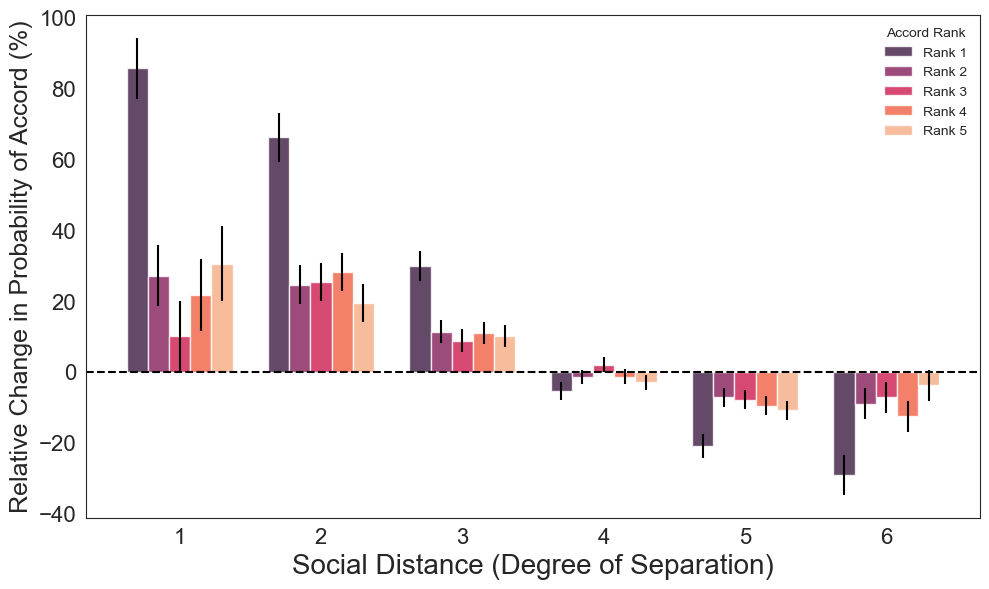


Summary of Relative Change (%) and Error by Degree of Separation (Averaged across Top 5 Ranks):
Degree	Mean_Relative_Increase	Std_Error
1	34.94			9.61
2	32.67			5.73
3	14.13			3.38
4	-1.89			2.17
5	-11.32			2.83
6	-12.34			4.61


In [6]:
import pandas as pd
import networkx as nx
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

# ───────────────────────────────────────────────────────────────────────────────
# Parsers
# ───────────────────────────────────────────────────────────────────────────────
def parse_perfumers(perfumer_str):
    """
    Parse the 'perfumer' column to extract individual perfumers.
    Handles stringified lists (via ast.literal_eval) or comma-separated strings.
    """
    try:
        if pd.isna(perfumer_str):
            return []
        s = str(perfumer_str).strip()
        if s.startswith('[') and s.endswith(']'):
            parsed = ast.literal_eval(s)
            if isinstance(parsed, list):
                return [str(name).strip() for name in parsed if str(name).strip()]
            else:
                cleaned = str(parsed).strip()
                return [cleaned] if cleaned else []
        else:
            return [p.strip() for p in s.split(",") if p.strip()]
    except Exception:
        return []

def parse_accords(accords_str):
    """
    Parse the 'accords' column (JSON-like string) to extract accord frequencies.
    Returns a dict {accord_name: value}. Values are ignored for counting; presence matters.
    """
    if pd.isna(accords_str):
        return {}
    try:
        return ast.literal_eval(accords_str)
    except (ValueError, SyntaxError):
        return {}

# ───────────────────────────────────────────────────────────────────────────────
# Network construction
# ───────────────────────────────────────────────────────────────────────────────
def build_network(df):
    """
    Build a perfumer collaboration network from rows where 'filtered_perfumers' has ≥2.
    Edge weight = number of co-works (not used later for distances).
    Keep only the largest connected component.
    """
    edge_weights = {}
    for perfumers in df['filtered_perfumers']:
        if len(perfumers) < 2:
            continue
        for pair in combinations(perfumers, 2):
            pair = tuple(sorted(pair))
            edge_weights[pair] = edge_weights.get(pair, 0) + 1

    G = nx.Graph()
    for (u, v), w in edge_weights.items():
        G.add_edge(u, v, weight=w)

    if G.number_of_nodes() == 0:
        return G
    largest_cc = max(nx.connected_components(G), key=len)
    return G.subgraph(largest_cc).copy()

# ───────────────────────────────────────────────────────────────────────────────
# Top-N accords per perfumer (global labels)
# ───────────────────────────────────────────────────────────────────────────────
def calculate_top_n_accords(perfumer_accords, n=5):
    """
    Given rows of {perfumer, accord, count}, compute normalized counts per perfumer,
    sort, keep top-n, and assign rank 1..n.
    Returns columns: [perfumer, accord, normalized_count, rank].
    """
    perfumer_accords_count = (
        perfumer_accords
        .groupby(['perfumer', 'accord'], as_index=False)['count']
        .sum()
    )
    total = perfumer_accords_count.groupby('perfumer')['count'].transform('sum')
    perfumer_accords_count['normalized_count'] = perfumer_accords_count['count'] / total

    aggregated = perfumer_accords_count.sort_values(
        ['perfumer', 'normalized_count'], ascending=[True, False]
    )
    top_df = aggregated.groupby('perfumer').head(n).copy()

    top_df['rank'] = (
        top_df.groupby('perfumer')['normalized_count']
        .rank(method='first', ascending=False)
        .astype(int)
    )
    return top_df[top_df['rank'] <= n]

def get_rank_accord_map(top_accords_df, rank):
    """For a given rank, return {perfumer: accord}."""
    rank_df = top_accords_df[top_accords_df['rank'] == rank]
    return rank_df.set_index('perfumer')['accord'].to_dict()

# ───────────────────────────────────────────────────────────────────────────────
# === NEW: Count structures for pair-specific exclusion at distance 1 ==========
# ───────────────────────────────────────────────────────────────────────────────
def build_count_structures(df, perfumer_accords):
    """
    Build:
      - total_counts: {perfumer: {accord: count across ALL their works}}
      - partner_counts: {p: {q: {accord: count from perfumes where BOTH p and q appear}}}
    Counting is presence-based: each (perfumer, accord) occurrence per perfume contributes +1.
    """
    # total_counts from perfumer_accords
    total_counts = {}
    for _, row in perfumer_accords.iterrows():
        p = row['perfumer']
        a = row['accord']
        total_counts.setdefault(p, {})
        total_counts[p][a] = total_counts[p].get(a, 0) + 1

    # partner_counts from per-row coauthorship
    partner_counts = {}  # nested dict
    for _, row in df.iterrows():
        perfumers = row['parsed_perfumers']
        accords_dict = row['parsed_accords']
        if not perfumers or not accords_dict:
            continue
        accords = list(accords_dict.keys())
        # ordered pairs (p,q), p != q
        for p in perfumers:
            partner_counts.setdefault(p, {})
            for q in perfumers:
                if p == q:
                    continue
                partner_counts[p].setdefault(q, {})
                for a in accords:
                    partner_counts[p][q][a] = partner_counts[p][q].get(a, 0) + 1

    return total_counts, partner_counts

def _subtract_counts(counts_a, counts_b):
    """
    Elementwise subtraction of two accord-count dicts; floor at zero and drop zeros.
    """
    if counts_a is None:
        return {}
    b = counts_b or {}
    out = {}
    for acc, ca in counts_a.items():
        cb = b.get(acc, 0)
        val = ca - cb
        if val > 0:
            out[acc] = val
    return out

def _rank_from_counts(counts_dict, rank_index):
    """
    From a dict {accord: count}, compute normalized counts and return the accord
    at a given rank (1-based). Returns None if unavailable.
    """
    if not counts_dict:
        return None
    total = sum(counts_dict.values())
    if total <= 0:
        return None
    # sort by normalized_count desc, tie-breaker by accord name for determinism
    items = sorted(
        ((acc, cnt / total) for acc, cnt in counts_dict.items()),
        key=lambda x: (-x[1], x[0])
    )
    if 1 <= rank_index <= len(items):
        return items[rank_index - 1][0]
    return None

# ───────────────────────────────────────────────────────────────────────────────
# Observed probabilities with pair-specific exclusion at d=1
# ───────────────────────────────────────────────────────────────────────────────
def compute_observed_with_pair_exclusion(
    G,
    total_counts,
    partner_counts,
    global_rank_labels,
    max_distance=6,
    n_ranks=5
):
    """
    Compute observed P(same accord) at each distance for ranks 1..n_ranks.
    For distance == 1, each node's rank-r label is recomputed EXCLUDING joint works
    with the specific partner (pair-specific exclusion). For distances >= 2,
    use global_rank_labels.
    Returns:
      observed_probs_by_rank: {rank: {distance: prob}}
      totals_by_distance:     {distance: total_pairs_count}
    """
    if G.number_of_nodes() == 0:
        return {r: {d: 0.0 for d in range(1, max_distance+1)} for r in range(1, n_ranks+1)}, \
               {d: 0 for d in range(1, max_distance+1)}

    distances = dict(nx.all_pairs_shortest_path_length(G))

    # Totals identical across ranks; count all ordered pairs at each distance.
    totals_by_distance = {d: 0 for d in range(1, max_distance+1)}
    observed_counts_by_rank = {r: {d: 0 for d in range(1, max_distance+1)} for r in range(1, n_ranks+1)}

    for u in distances:
        for v, dist in distances[u].items():
            if u == v:
                continue
            if 1 <= dist <= max_distance:
                totals_by_distance[dist] += 1

                for r in range(1, n_ranks+1):
                    if dist == 1:
                        # Pair-specific exclusion for (u,v)
                        u_counts_ex = _subtract_counts(total_counts.get(u), partner_counts.get(u, {}).get(v))
                        v_counts_ex = _subtract_counts(total_counts.get(v), partner_counts.get(v, {}).get(u))
                        u_label = _rank_from_counts(u_counts_ex, r)
                        v_label = _rank_from_counts(v_counts_ex, r)
                    else:
                        # Use global rank labels for distances >= 2
                        u_labels = global_rank_labels.get(u, [])
                        v_labels = global_rank_labels.get(v, [])
                        u_label = u_labels[r-1] if len(u_labels) >= r else None
                        v_label = v_labels[r-1] if len(v_labels) >= r else None

                    if (u_label is not None) and (v_label is not None) and (u_label == v_label):
                        observed_counts_by_rank[r][dist] += 1

    observed_probs_by_rank = {
        r: {
            d: (observed_counts_by_rank[r][d] / totals_by_distance[d]) if totals_by_distance[d] > 0 else 0.0
            for d in range(1, max_distance+1)
        }
        for r in range(1, n_ranks+1)
    }
    return observed_probs_by_rank, totals_by_distance

# ───────────────────────────────────────────────────────────────────────────────
# Null (random) probabilities — node-label shuffle (as before)
# Note: For d=1 this null does NOT re-do pair-specific exclusion; it provides a
#       baseline under random label assignment across nodes.
# ───────────────────────────────────────────────────────────────────────────────
def compute_probability_by_distance_for_map(G, perfumer_accord_map, max_distance=6):
    """
    Classic helper used for null simulations: given a node→accord map for ONE rank,
    compute P(same accord) at each distance (counts all ordered pairs).
    """
    if G.number_of_nodes() == 0:
        return {d: 0.0 for d in range(1, max_distance+1)}

    distances = dict(nx.all_pairs_shortest_path_length(G))
    observed_counts = {d: 0 for d in range(1, max_distance+1)}
    total_counts = {d: 0 for d in range(1, max_distance+1)}

    for u in distances:
        for v, dist in distances[u].items():
            if u == v:
                continue
            if 1 <= dist <= max_distance:
                total_counts[dist] += 1
                if (u in perfumer_accord_map) and (v in perfumer_accord_map):
                    if perfumer_accord_map[u] is not None and perfumer_accord_map[v] is not None:
                        if perfumer_accord_map[u] == perfumer_accord_map[v]:
                            observed_counts[dist] += 1

    return {
        d: (observed_counts[d] / total_counts[d]) if total_counts[d] > 0 else 0.0
        for d in range(1, max_distance+1)
    }

def simulate_random_networks_for_map(G, perfumer_accord_map, num_simulations=50, max_distance=6):
    """
    Shuffle the accord assignments among existing nodes (including None for unlabeled).
    Return random mean and std across simulations: {distance: mean}, {distance: std}.
    """
    if G.number_of_nodes() == 0:
        zero = {d: 0.0 for d in range(1, max_distance+1)}
        return zero, zero

    nodes = list(G.nodes())
    labels = [perfumer_accord_map.get(n, None) for n in nodes]

    probs_per_sim = []
    for _ in range(num_simulations):
        np.random.shuffle(labels)
        shuffled_map = dict(zip(nodes, labels))
        probs = compute_probability_by_distance_for_map(G, shuffled_map, max_distance=max_distance)
        probs_per_sim.append(probs)

    random_mean = {d: np.mean([sim[d] for sim in probs_per_sim]) for d in range(1, max_distance+1)}
    random_std  = {d: np.std([sim[d] for sim in probs_per_sim], ddof=1) for d in range(1, max_distance+1)}
    return random_mean, random_std

# ───────────────────────────────────────────────────────────────────────────────
# Main
# ───────────────────────────────────────────────────────────────────────────────
def main():
    # -------------------------------
    # 1) Load CSV
    # -------------------------------
    csv_file = "../dataset/perfume_dataset.csv"
    df = pd.read_csv(csv_file)
    # df = df[df['weights_sum'] > 286].copy()  # optional filter

    # -------------------------------
    # 2) Parse perfumers & accords
    # -------------------------------
    df['parsed_perfumers'] = df['perfumer'].apply(parse_perfumers)
    df['parsed_accords']   = df['accords'].apply(parse_accords)

    # -------------------------------
    # 3) Build perfumer_accords (presence-based)
    #    Keep perfume id for reference if needed.
    # -------------------------------
    # Prefer 'id' if present; fallback to index
    perfume_id_col = 'id' if 'id' in df.columns else None

    perfumer_accords_rows = []
    for idx, row in df.iterrows():
        pid = row[perfume_id_col] if perfume_id_col else idx
        perfumers = row['parsed_perfumers']
        accords_dict = row['parsed_accords']
        if not perfumers or not accords_dict:
            continue
        for p in perfumers:
            for acc in accords_dict.keys():
                perfumer_accords_rows.append({
                    'perfume_id': pid,
                    'perfumer': p,
                    'accord': acc,
                    'count': 1
                })

    perfumer_accords = pd.DataFrame(perfumer_accords_rows)
    if perfumer_accords.empty:
        print("No perfumer_accords found. Check CSV parsing.")
        return

    # -------------------------------
    # 4) Global top-5 accords per perfumer (labels)
    # -------------------------------
    top_5_df = calculate_top_n_accords(perfumer_accords, n=5)
    if top_5_df.empty:
        print("No top-5 accords found. Possibly no data or mismatch.")
        return

    # Build global labels as {perfumer: [rank1, rank2, ...]}
    global_rank_labels = {}
    for p, grp in top_5_df.sort_values(['perfumer','rank']).groupby('perfumer'):
        labels = [None]*5
        for _, r in grp.iterrows():
            labels[r['rank']-1] = r['accord']
        # Trim trailing None for cleanliness (keep list length variable)
        while labels and labels[-1] is None:
            labels.pop()
        global_rank_labels[p] = labels

    # -------------------------------
    # 5) Build collaboration network
    #    Use only perfumers that appear in top-5 list to filter rows.
    # -------------------------------
    top_perfumers = set(top_5_df['perfumer'].unique())
    df['filtered_perfumers'] = df['parsed_perfumers'].apply(
        lambda xs: [p for p in xs if p in top_perfumers]
    )
    df_net = df[df['filtered_perfumers'].apply(len) > 1].copy()

    G = build_network(df_net)
    if G.number_of_nodes() == 0:
        print("Network is empty or only has isolated nodes. No plot will be generated.")
        return

    # -------------------------------
    # 6) === NEW: Count structures for pair-specific exclusion
    # -------------------------------
    total_counts, partner_counts = build_count_structures(df, perfumer_accords)

    max_dist = 6
    n_ranks  = 5

    # -------------------------------
    # 7) Observed probabilities with pair exclusion at d=1
    # -------------------------------
    observed_probs_by_rank, totals_by_distance = compute_observed_with_pair_exclusion(
        G,
        total_counts,
        partner_counts,
        global_rank_labels,
        max_distance=max_dist,
        n_ranks=n_ranks
    )

    # -------------------------------
    # 8) Null (random) via node-label shuffle (rank-wise)
    #     Note: For d=1 this null does not apply pair-exclusion; it is a baseline.
    # -------------------------------
    random_mean_by_rank = {}
    random_std_by_rank  = {}
    for rank in range(1, n_ranks+1):
        # Build global rank map for this rank (may contain None)
        rank_map = {p: (global_rank_labels.get(p, [None]*n_ranks)[rank-1]
                        if len(global_rank_labels.get(p, [])) >= rank else None)
                    for p in G.nodes()}
        r_mean, r_std = simulate_random_networks_for_map(
            G, rank_map, num_simulations=10000, max_distance=max_dist
        )
        random_mean_by_rank[rank] = r_mean
        random_std_by_rank[rank]  = r_std

    # -------------------------------
    # 9) Relative increase & error bars
    # -------------------------------
    relative_increase = {r: {} for r in range(1, n_ranks+1)}
    relative_increase_err = {r: {} for r in range(1, n_ranks+1)}

    for r in range(1, n_ranks+1):
        for d in range(1, max_dist+1):
            obs = observed_probs_by_rank[r][d]
            mu  = random_mean_by_rank[r][d]
            sd  = random_std_by_rank[r][d]
            if mu > 0:
                relative_increase[r][d] = (obs - mu) / mu * 100.0
                relative_increase_err[r][d] = (sd / mu) * 100.0
            else:
                relative_increase[r][d] = 0.0
                relative_increase_err[r][d] = 0.0

    # -------------------------------
    # 10) Plot grouped bars (ranks 1..5 across distances)
    # -------------------------------
    sns.set_style("white")
    palette = sns.color_palette("rocket", n_ranks)

    distances = np.arange(1, max_dist+1)
    width = 0.15
    offset = -(n_ranks//2) * width

    plt.figure(figsize=(10, 6))
    for i, rank in enumerate(range(1, n_ranks+1)):
        ri_vals = [relative_increase[rank][d] for d in distances]
        ri_errs = [relative_increase_err[rank][d] for d in distances]
        x_pos = distances + offset + i * width
        plt.bar(
            x_pos, ri_vals, yerr=ri_errs, width=width,
            color=palette[i], alpha=0.8, label=f"Rank {rank}"
        )

    plt.xticks(distances, distances)
    plt.axhline(y=0, color='black', linestyle='dashed')
    plt.xlabel("Social Distance (Degree of Separation)", fontsize=20)
    plt.ylabel("Relative Change in Probability of Accord (%)", fontsize=18)
    plt.legend(title="Accord Rank", frameon=False)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.tight_layout()
    plt.savefig("../output/Figure_4c.svg", format="svg", dpi=300, bbox_inches="tight")
    plt.show()

    # -------------------------------
    # 11) Print summary table
    # -------------------------------
    print("\nSummary of Relative Change (%) and Error by Degree of Separation (Averaged across Top 5 Ranks):")
    print("Degree\tMean_Relative_Increase\tStd_Error")
    for d in distances:
        mean_ri  = np.mean([relative_increase[rank][d] for rank in range(1, n_ranks+1)])
        mean_err = np.mean([relative_increase_err[rank][d] for rank in range(1, n_ranks+1)])
        print(f"{d}\t{mean_ri:.2f}\t\t\t{mean_err:.2f}")

if __name__ == "__main__":
    main()


In [ ]:
import pandas as pd
import networkx as nx
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

# ───────────────────────── Parsers ─────────────────────────
def parse_perfumers(perfumer_str):
    try:
        if pd.isna(perfumer_str):
            return []
        s = str(perfumer_str).strip()
        if s.startswith('[') and s.endswith(']'):
            parsed = ast.literal_eval(s)
            if isinstance(parsed, list):
                return [str(x).strip() for x in parsed if str(x).strip()]
            s = str(parsed).strip()
            return [s] if s else []
        return [p.strip() for p in s.split(',') if p.strip()]
    except Exception:
        return []

def parse_top_notes(notes_str):
    if pd.isna(notes_str):
        return []
    try:
        raw = ast.literal_eval(notes_str)
        out = []
        for d in raw:
            for note in d.keys():
                out.append(str(note))
        return out
    except Exception:
        return []

# ───────────────────────── Network ─────────────────────────
def build_network(df):
    edge_weights = {}
    for perfumers in df['filtered_perfumers']:
        if len(perfumers) < 2:
            continue
        for a, b in combinations(perfumers, 2):
            pair = tuple(sorted((a, b)))
            edge_weights[pair] = edge_weights.get(pair, 0) + 1

    G = nx.Graph()
    for (u, v), w in edge_weights.items():
        G.add_edge(u, v, weight=w)

    if G.number_of_nodes() == 0:
        return G
    largest_cc = max(nx.connected_components(G), key=len)
    return G.subgraph(largest_cc).copy()

# ───────────────── Top-N notes (global labels) ─────────────
def calculate_top_n_notes(perfumer_notes, top_notes, n=5):
    agg = (
        perfumer_notes
        .groupby(['perfumer', 'note'], as_index=False)['count']
        .sum()
    )
    totals = agg.groupby('perfumer')['count'].transform('sum')
    agg['normalized_count'] = agg['count'] / totals
    agg = agg.sort_values(['perfumer', 'normalized_count'], ascending=[True, False])

    top_df = agg.groupby('perfumer').head(n).copy()
    top_df['rank'] = (
        top_df.groupby('perfumer')['normalized_count']
        .rank(method='first', ascending=False)
        .astype(int)
    )
    return top_df[top_df['rank'] <= n]

def get_rank_note_map(top_notes_df, rank):
    r = top_notes_df[top_notes_df['rank'] == rank]
    return r.set_index('perfumer')['note'].to_dict()

# ─────────── Pair-specific exclusion count structures ──────
def build_count_structures(df, perfumer_notes):
    """
    total_counts[p][note]: occurrences across ALL works of p
    partner_counts[p][q][note]: occurrences from perfumes where p and q coauthored
    (presence-based counting)
    """
    total_counts = {}
    for _, row in perfumer_notes.iterrows():
        p, note = row['perfumer'], row['note']
        total_counts.setdefault(p, {})
        total_counts[p][note] = total_counts[p].get(note, 0) + 1

    partner_counts = {}
    for _, row in df.iterrows():
        perfumers = row['parsed_perfumers']
        notes = row['parsed_top_notes']
        if not perfumers or not notes:
            continue
        for p in perfumers:
            partner_counts.setdefault(p, {})
            for q in perfumers:
                if p == q:
                    continue
                partner_counts[p].setdefault(q, {})
                for note in notes:
                    partner_counts[p][q][note] = partner_counts[p][q].get(note, 0) + 1

    return total_counts, partner_counts

def _subtract_counts(total_dict, partner_dict):
    if not total_dict:
        return {}
    partner_dict = partner_dict or {}
    out = {}
    for k, v in total_dict.items():
        val = v - partner_dict.get(k, 0)
        if val > 0:
            out[k] = val
    return out

def _rank_from_counts(counts_dict, rank_idx):
    if not counts_dict:
        return None
    total = sum(counts_dict.values())
    if total <= 0:
        return None
    items = sorted(((note, c / total) for note, c in counts_dict.items()),
                   key=lambda x: (-x[1], x[0]))
    if 1 <= rank_idx <= len(items):
        return items[rank_idx - 1][0]
    return None

# ───────────────────── Probabilities ───────────────────────
def compute_observed_with_pair_exclusion_notes(
    G, total_counts, partner_counts, global_rank_labels,
    max_distance=6, n_ranks=5
):
    if G.number_of_nodes() == 0:
        return {r: {d: 0.0 for d in range(1, max_distance+1)} for r in range(1, n_ranks+1)}, \
               {d: 0 for d in range(1, max_distance+1)}

    dist_map = dict(nx.all_pairs_shortest_path_length(G))
    totals_by_distance = {d: 0 for d in range(1, max_distance+1)}
    matches_by_rank = {r: {d: 0 for d in range(1, max_distance+1)} for r in range(1, n_ranks+1)}

    for u in dist_map:
        for v, d in dist_map[u].items():
            if u == v or not (1 <= d <= max_distance):
                continue
            totals_by_distance[d] += 1

            for r in range(1, n_ranks+1):
                if d == 1:
                    u_ex = _subtract_counts(total_counts.get(u), partner_counts.get(u, {}).get(v))
                    v_ex = _subtract_counts(total_counts.get(v), partner_counts.get(v, {}).get(u))
                    u_label = _rank_from_counts(u_ex, r)
                    v_label = _rank_from_counts(v_ex, r)
                else:
                    u_labels = global_rank_labels.get(u, [])
                    v_labels = global_rank_labels.get(v, [])
                    u_label = u_labels[r-1] if len(u_labels) >= r else None
                    v_label = v_labels[r-1] if len(v_labels) >= r else None

                if (u_label is not None) and (v_label is not None) and (u_label == v_label):
                    matches_by_rank[r][d] += 1

    observed = {
        r: {d: (matches_by_rank[r][d] / totals_by_distance[d]) if totals_by_distance[d] > 0 else 0.0
            for d in range(1, max_distance+1)}
        for r in range(1, n_ranks+1)
    }
    return observed, totals_by_distance

def compute_probability_by_distance_for_map(G, perfumer_note_map, max_distance=6):
    if G.number_of_nodes() == 0:
        return {d: 0.0 for d in range(1, max_distance+1)}

    dist_map = dict(nx.all_pairs_shortest_path_length(G))
    matches = {d: 0 for d in range(1, max_distance+1)}
    totals  = {d: 0 for d in range(1, max_distance+1)}

    for u in dist_map:
        for v, d in dist_map[u].items():
            if u == v or not (1 <= d <= max_distance):
                continue
            totals[d] += 1
            a = perfumer_note_map.get(u, None)
            b = perfumer_note_map.get(v, None)
            if (a is not None) and (b is not None) and (a == b):
                matches[d] += 1

    return {d: (matches[d] / totals[d]) if totals[d] > 0 else 0.0 for d in range(1, max_distance+1)}

def simulate_random_networks_for_map(G, perfumer_note_map, num_simulations=10000, max_distance=6):
    if G.number_of_nodes() == 0:
        zero = {d: 0.0 for d in range(1, max_distance+1)}
        return zero, zero

    nodes = list(G.nodes())
    labels = [perfumer_note_map.get(n, None) for n in nodes]

    sims = []
    for _ in range(num_simulations):
        np.random.shuffle(labels)
        shuffled = dict(zip(nodes, labels))
        sims.append(compute_probability_by_distance_for_map(G, shuffled, max_distance=max_distance))

    mean = {d: np.mean([s[d] for s in sims]) for d in range(1, max_distance+1)}
    std  = {d: np.std([s[d] for s in sims], ddof=1) for d in range(1, max_distance+1)}
    return mean, std

# ─────────────────────────── Main ──────────────────────────
def main():
    # 1) Load CSV
    csv_file = "../dataset/perfume_dataset.csv"
    df = pd.read_csv(csv_file)

    # Optional filter
    df = df[df['weights_sum'] > 10].copy()

    # 2) Parse perfumers & notes
    df['parsed_perfumers'] = df['perfumer'].apply(parse_perfumers)
    df['parsed_top_notes'] = df['notes'].apply(parse_top_notes)

    # 3) Build perfumer_notes (presence-based). Keep perfume_id if available.
    pid_col = 'id' if 'id' in df.columns else None
    rows = []
    for idx, row in df.iterrows():
        pid = row[pid_col] if pid_col else idx
        perfumers = row['parsed_perfumers']
        notes = row['parsed_top_notes']
        if not perfumers or not notes:
            continue
        for p in perfumers:
            for note in notes:
                rows.append({'perfume_id': pid, 'perfumer': p, 'note': note, 'count': 1})
    perfumer_notes = pd.DataFrame(rows)
    if perfumer_notes.empty:
        print("No perfumer_notes found. Check CSV parsing.")
        return

    # 4) Global top-5 notes per perfumer (labels)
    top_notes = perfumer_notes.groupby('note')['count'].sum().sort_values(ascending=False).index.tolist()
    top_5_df = calculate_top_n_notes(perfumer_notes, top_notes, n=5)
    if top_5_df.empty:
        print("No top-5 notes found. Possibly no data or mismatch.")
        return

    # {perfumer: [rank1, rank2, ...]}
    global_rank_labels = {}
    for p, grp in top_5_df.sort_values(['perfumer', 'rank']).groupby('perfumer'):
        labels = [None] * 5
        for _, r in grp.iterrows():
            labels[r['rank'] - 1] = r['note']
        while labels and labels[-1] is None:
            labels.pop()
        global_rank_labels[p] = labels

    # 5) Build network using only labeled perfumers
    labeled = set(top_5_df['perfumer'].unique())
    df['filtered_perfumers'] = df['parsed_perfumers'].apply(lambda xs: [p for p in xs if p in labeled])
    df_net = df[df['filtered_perfumers'].apply(len) > 1].copy()
    G = build_network(df_net)
    if G.number_of_nodes() == 0:
        print("Network is empty or has only isolated nodes. No plot will be generated.")
        return

    # 6) Build count structures for pair-specific exclusion (FIX: no stray join)
    total_counts, partner_counts = build_count_structures(df, perfumer_notes)

    max_dist = 6
    n_ranks  = 5

    # 7) Observed with pair-specific exclusion at d=1
    observed_probs_by_rank, totals_by_distance = compute_observed_with_pair_exclusion_notes(
        G, total_counts, partner_counts, global_rank_labels,
        max_distance=max_dist, n_ranks=n_ranks
    )

    # 8) Null (shuffle node labels) per rank
    random_mean_by_rank = {}
    random_std_by_rank  = {}
    for rank in range(1, n_ranks + 1):
        rank_map = {
            p: (global_rank_labels.get(p, [None] * n_ranks)[rank - 1]
                if len(global_rank_labels.get(p, [])) >= rank else None)
            for p in G.nodes()
        }
        r_mean, r_std = simulate_random_networks_for_map(
            G, rank_map, num_simulations=10000, max_distance=max_dist
        )
        random_mean_by_rank[rank] = r_mean
        random_std_by_rank[rank] = r_std

    # 9) Relative increase (%) and error proxy
    relative_increase = {r: {} for r in range(1, n_ranks + 1)}
    relative_increase_err = {r: {} for r in range(1, n_ranks + 1)}
    for r in range(1, n_ranks + 1):
        for d in range(1, max_dist + 1):
            obs = observed_probs_by_rank[r][d]
            mu  = random_mean_by_rank[r][d]
            sd  = random_std_by_rank[r][d]
            if mu > 0:
                relative_increase[r][d] = (obs - mu) / mu * 100.0
                relative_increase_err[r][d] = (sd / mu) * 100.0
            else:
                relative_increase[r][d] = 0.0
                relative_increase_err[r][d] = 0.0

    # 10) Plot
    sns.set_style("white")
    palette = sns.color_palette("rocket", n_ranks)

    distances = np.arange(1, max_dist + 1)
    width = 0.15
    offset = -(n_ranks // 2) * width

    plt.figure(figsize=(10, 6))
    for i, rank in enumerate(range(1, n_ranks + 1)):
        ri_vals = [relative_increase[rank][d] for d in distances]
        ri_errs = [relative_increase_err[rank][d] for d in distances]
        x_pos = distances + offset + i * width
        plt.bar(x_pos, ri_vals, yerr=ri_errs, width=width, color=palette[i], alpha=0.8, label=f"Rank {rank}")

    plt.xticks(distances, distances)
    plt.axhline(y=0, color='black', linestyle='dashed')
    plt.xlabel("Social Distance (Degree of Separation)", fontsize=20)
    plt.ylabel("Relative Change in Probability of Notes (%)", fontsize=18)
    plt.legend(title="Notes Rank", frameon=False)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.tight_layout()
    plt.savefig("../output/Figure_4d.svg", format="svg", dpi=300, bbox_inches="tight")
    plt.show()

    # 11) Summary
    print("\nSummary of Relative Change (%) and Error by Degree of Separation (Averaged across Top 5 Note Ranks):")
    print("Degree\tMean_Relative_Increase\tStd_Error")
    for d in distances:
        mean_ri  = np.mean([relative_increase[r][d] for r in range(1, n_ranks + 1)])
        mean_err = np.mean([relative_increase_err[r][d] for r in range(1, n_ranks + 1)])
        print(f"{d}\t{mean_ri:.2f}\t\t\t{mean_err:.2f}")

if __name__ == "__main__":
    main()


In [ ]:
import pandas as pd
import networkx as nx
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from scipy.stats import spearmanr  # For Spearman correlation

def parse_perfumers(perfumer_str):
    """
    Parse the 'perfumer' column to extract individual perfumers.
    If the cell is a string representation of a list, use ast.literal_eval.
    """
    try:
        if pd.isna(perfumer_str):
            return []
        s = perfumer_str.strip()
        if s.startswith('[') and s.endswith(']'):
            parsed = ast.literal_eval(s)
            if isinstance(parsed, list):
                return [str(name).strip() for name in parsed if str(name).strip()]
            else:
                cleaned = str(parsed).strip()
                return [cleaned] if cleaned else []
        else:
            return [p.strip() for p in s.split(",") if p.strip()]
    except Exception:
        return []

def build_network(df, perfumer_col='filtered_perfumers'):
    """
    Build a perfumer collaboration network from the DataFrame.
    Each row can have multiple perfumers; we create edges
    between every pair of perfumers in that row.
    """
    edge_weights = {}
    for perfumers in df[perfumer_col]:
        if len(perfumers) < 2:
            continue
        for pair in combinations(perfumers, 2):
            pair = tuple(sorted(pair))
            edge_weights[pair] = edge_weights.get(pair, 0) + 1

    G = nx.Graph()
    for (n1, n2), weight in edge_weights.items():
        G.add_edge(n1, n2, weight=weight)

    if G.number_of_nodes() == 0:
        return G

    # Extract the largest connected component
    largest_cc = max(nx.connected_components(G), key=len)
    G_sub = G.subgraph(largest_cc).copy()
    return G_sub

def main():
    # -------------------------------------------------
    # 1) Load CSV
    # -------------------------------------------------
    csv_file = "enhanced_with_ratings.csv"
    df = pd.read_csv(csv_file)

    # -------------------------------------------------
    # 2) Parse perfumers
    # -------------------------------------------------
    df['parsed_perfumers'] = df['perfumer'].apply(parse_perfumers)

    # -------------------------------------------------
    # 3) Build collaboration network
    # -------------------------------------------------
    df['filtered_perfumers'] = df['parsed_perfumers'].apply(lambda x: [p for p in x if p.strip()])
    df_for_network = df[df['filtered_perfumers'].apply(len) > 1].copy()

    G = build_network(df_for_network)
    if G.number_of_nodes() == 0:
        print("No connected network found. Exiting.")
        return

    # -------------------------------------------------
    # 4) Compute centralities: Eigenvector, Degree
    # -------------------------------------------------
    ec_dict = nx.eigenvector_centrality(G, max_iter=1000)  # {perfumer: eigenvector}
    deg_dict = dict(G.degree())                            # {perfumer: degree}

    centrality_df = pd.DataFrame({
        'perfumer': list(G.nodes()),
        'eigenvector': [ec_dict[n] for n in G.nodes()],
        'degree': [deg_dict[n] for n in G.nodes()]
    })

    # -------------------------------------------------
    # 5) Aggregate Perfume_Complexity + innovation_score
    #    capturing both mean & std for each perfumer
    # -------------------------------------------------
    expanded_rows = []
    for _, row in df.iterrows():
        complexity = row.get('Perfume_Complexity', np.nan)
        innovation = row.get('innovation_score', np.nan)
        for perf in row['parsed_perfumers']:
            expanded_rows.append({
                'perfumer': perf,
                'Perfume_Complexity': complexity,
                'innovation_score': innovation
            })

    expanded_df = pd.DataFrame(expanded_rows)
    stats_df = expanded_df.groupby('perfumer', as_index=False).agg({
        'Perfume_Complexity': ['mean', 'std'],
        'innovation_score': ['mean', 'std']
    })
    # Flatten multi-level columns
    stats_df.columns = [
        'perfumer',
        'Perfume_Complexity_mean', 'Perfume_Complexity_std',
        'innovation_score_mean', 'innovation_score_std'
    ]

    # -------------------------------------------------
    # 6) Merge centralities with stats
    # -------------------------------------------------
    merged = pd.merge(centrality_df, stats_df, on='perfumer', how='inner')
    merged.dropna(subset=[
        'eigenvector',
        'degree',
        'Perfume_Complexity_mean',
        'Perfume_Complexity_std',
        'innovation_score_mean',
        'innovation_score_std'
    ], inplace=True)

    # -------------------------------------------------
    # 7) Set Seaborn style
    # -------------------------------------------------
    sns.set_style("white")

    # -------------------------------------------------
    # 8) Plot 2×2:  Row=0 => Complexity; Row=1 => Innovation
    #               Col=0 => Eigenvector; Col=1 => Degree
    # -------------------------------------------------
    fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 9))

    def plot_reg_with_errorbars(ax, xvals, yvals, yerrs, x_label, y_label):
        # 1) Scatter + error bars
        ax.errorbar(xvals, yvals, yerr=yerrs, fmt='o', alpha=0.6, color='steelblue',zorder=1)

        # 2) Regression line
        temp_df = pd.DataFrame({'x': xvals, 'y': yvals})
        sns.regplot(
            x='x', y='y',
            data=temp_df,
            ci=95,
            scatter=False,
            color='red',
            ax=ax,
            line_kws={'zorder': 2}
        )

        # 3) Spearman correlation
        rho, pval = spearmanr(xvals, yvals)
        pval_formatted = round(float(f"{pval:.2g}"), 4)
        text_str = f"$\\it{{\\rho}}$ = {rho:.2f}\np = {pval_formatted}"
        ax.text(
            0.6, 0.95, text_str,
            transform=ax.transAxes,
            fontsize=18,
            verticalalignment='top',
            bbox=dict(facecolor='white', alpha=1, boxstyle='round')
        )

        # 4) Aesthetics
        ax.set_xlabel(x_label, fontsize=22)
        ax.set_ylabel(y_label, fontsize=22)
        ax.tick_params(labelsize=18)
        ax.grid(False)


    # ========== Subplots ==========

    # (0, 0) => Eigenvector vs. Complexity
    plot_reg_with_errorbars(
        axs[0, 1],
        merged['eigenvector'],
        merged['Perfume_Complexity_mean'],
        merged['Perfume_Complexity_std'],
        x_label="",  # or "Eigenvector Centrality"
        y_label=""
    )

    # (0, 1) => Degree vs. Complexity
    plot_reg_with_errorbars(
        axs[0, 0],
        merged['degree'],
        merged['Perfume_Complexity_mean'],
        merged['Perfume_Complexity_std'],
        x_label="",
        y_label="Perfume Complexity"
    )

    # (1, 0) => Eigenvector vs. Innovation
    plot_reg_with_errorbars(
        axs[1, 1],
        merged['eigenvector'],
        merged['innovation_score_mean'],
        merged['innovation_score_std'],
        x_label="Perfumer Eigenvector Centrality",
        y_label=""
    )

    # (1, 1) => Degree vs. Innovation
    plot_reg_with_errorbars(
        axs[1, 0],
        merged['degree'],
        merged['innovation_score_mean'],
        merged['innovation_score_std'],
        x_label="Perfumer Degree",
        y_label="Perfume Innovation"
    )

    plt.tight_layout(rect=[0,0,1,1])
    plt.savefig("../output/Figure_4e.svg", format="svg", dpi=300, bbox_inches="tight")


    plt.show()

if __name__ == "__main__":
    main()
